x的形状: (42000, 784)
y的形状: (42000,)
查看所有标签的分布情况: Counter({1: 4684, 7: 4401, 3: 4351, 9: 4188, 2: 4177, 6: 4137, 0: 4132, 4: 4072, 8: 4063, 5: 3795})
准确率: 0.9670238095238095
准确率: 0.9670238095238095
模型保存成功!


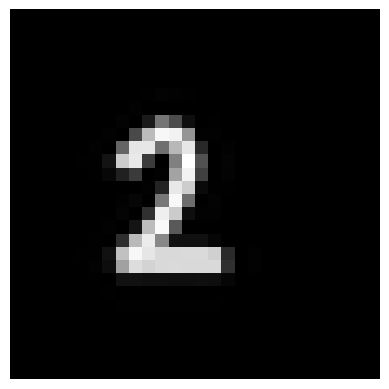

(28, 28)
(1, 784)
(1, 784)
预测值为: [2]


In [13]:
import csv

import sklearn
from sklearn.metrics import accuracy_score
from sklearn.utils._repr_html import estimator

"""
案例:演示 识别图片,即: 手写数字识别案例

介绍:
    每张图片都是由28x28的像素点组成的,即:csv文件中每一行都有784个像素点,表示图片的颜色.最终构成图像
"""

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import joblib
from collections import Counter

# 扩展:忽略警告
import warnings

warnings.filterwarnings('ignore', module='sklearn')


# 1.定义函数,接收用户传入的索引,展示该索引对应的图片
def show_digit(idx):
    # 1.读取数据集,获取源数据
    df = pd.read_csv('../data/手写数字识别.csv')
    # print(df)
    # 2. 判断传入的索引是否越界
    if idx < 0 or idx > len(df) - 1:
        print("索引越界")
        return

        # 3.无越界,正常获取数据
    x = df.iloc[:, 1:]
    y = df.iloc[:, 0:]

    # 4.查看用户传入的索引对应的图片 -> 是几?
    print(f"该图片对应的数字是: {y.iloc[idx]}")
    print(f"查看所有标签的分布情况: {Counter(y)}")

    # 5.查看下,用户传入的索引对应的图片的形状
    print(x.iloc[idx].shape)
    # print(x.iloc[idx].values)

    # 6.把784转为(28,28)
    x = x.iloc[idx].values.reshape(28, 28)
    print(x)

    # 7.展示图片
    plt.imshow(x, cmap='gray')
    plt.axis('off')
    plt.show()


# 2.定义函数,训练模型,并保存训练好的模型
def train_model():
    # 1.加载数据集
    df = pd.read_csv('../data/手写数字识别.csv')
    # 2.数据的预处理
    # 2.1 拆分出特征列
    x = df.iloc[:, 1:]
    # 2.2 拆分出标签列
    y = df.iloc[:, 0]
    # 2.3 打印特征和标签的形状
    print(f"x的形状: {x.shape}")
    print(f"y的形状: {y.shape}")
    print(f"查看所有标签的分布情况: {Counter(y)}")

    # 2.4 对特征列(拆分前)进行归一化处理
    x = x / 255

    # 2.5 划分训练集和测试集
    # 参1:特征列    参2:标签列    -->>>随机种子的取值可能会影响模型最后的预测结果
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=50, stratify=y)

    # 3.模型训练
    # 3.1 创建模型对象
    estimator = KNeighborsClassifier(n_neighbors=3)
    # 3.2 模型训练
    estimator.fit(x_train, y_train)

    # 4.模型评估
    print(f"准确率: {estimator.score(x_test, y_test)}")
    print(f"准确率: {accuracy_score(y_test, estimator.predict(x_test))}")

    # 5.保存模型
    joblib.dump(estimator, '../ML-model/digit_recognition_model.pkl')
    print("模型保存成功!")


# 3.定义函数,测试模型
def use_model():
    # 1.加载图片
    x = plt.imread('../data/demo.png')
    # 2. 绘制图片
    plt.imshow(x, cmap='gray')
    plt.axis('off')
    plt.show()

    # 3.加载模型
    estimator = joblib.load('../ML-model/digit_recognition_model.pkl')

    # 4.模型预测
    # 4.1 查看,数据集转换
    print(x.shape)
    print(x.reshape(1, 784).shape)
    print(x.reshape(1, -1).shape)  # 语法糖,效果同上

    # 4.2 具体的转换动作, 记得: 归一化(因为训练模型的时候 使用了会议化处理)
    # x = x.reshape(1, -1) / 255  # 可能会预测失败,因为读图的时候,像素可能不是特别精准.
    x = x.reshape(1, -1)

    # 4.3 模型预测
    y_pred = estimator.predict(x)

    # 5. 打印预测结果
    print(f"预测值为: {y_pred}")


if __name__ == '__main__':
    # show_digit(28)

    train_model()

    use_model()
